In [1]:
import glob
from scalesurfer.config import DATA_PATH, MODULE_PATH, SEED
from scalesurfer.experiments import build_v8_split_from_root
from scalesurfer import ScaleSurfer

In [2]:
# load dataset and model
BASE_PATH = MODULE_PATH.parent
FS_VERSION_JSON = BASE_PATH / "data" /"fs_version_by_dataset_updated.json"
TENSORS_ROOT_V8 = BASE_PATH / "data" / "tensors_gcloud"
RANDOM_SEED = int(SEED)
SPLIT_RATIOS = (0.8, 0.1, 0.1)
split_v8 = build_v8_split_from_root(
    tensors_root=TENSORS_ROOT_V8,
    seed=RANDOM_SEED,
    ratios=SPLIT_RATIOS
)

# test set
ds = [i[42:50] for i in split_v8["x_test"]]
nii = glob.glob("/home/rph/scalesurfer/data/openneuro_test_set_raw/files/**/*.ni*", recursive=True)
nii = {i[56:64]: i for i in nii}
ds = {i: nii[i] for i in ds}

In [18]:
# image paths
images = list(ds.values())[1:2]
images

['/home/rph/scalesurfer/data/openneuro_test_set_raw/files/ds003720/sub-005/anat/sub-005_T1w.nii']

In [19]:
# names of the ouput dirs in subject_dir
subjects = list(ds.keys())[1:2]
subjects

['ds003720']

In [20]:
# Initialize object
surfer = ScaleSurfer(
    images,
    subjects,
    DATA_PATH / "subjects_dir",
    in_memory=True, # store all tensors in memory
    device="cuda"
)

In [21]:
surfer.prepare_images() # saves subject_dir/*/mri/rawavg.pt

Converting niftis to tensors:   0%|          | 0/1 [00:00<?, ?it/s]

In [22]:
surfer.predict_volumes() # saves subject_dir/*/mri/aparc+aseg.pt

Predicting volumes:   0%|          | 0/1 [00:00<?, ?it/s]

In [23]:
surfer.predict_surfaces() # save subject_dir/*/surf/{lh.white, rh.white, lh.pial, rh.pial}

Predicting surfaces:   0%|          | 0/1 [00:00<?, ?it/s]

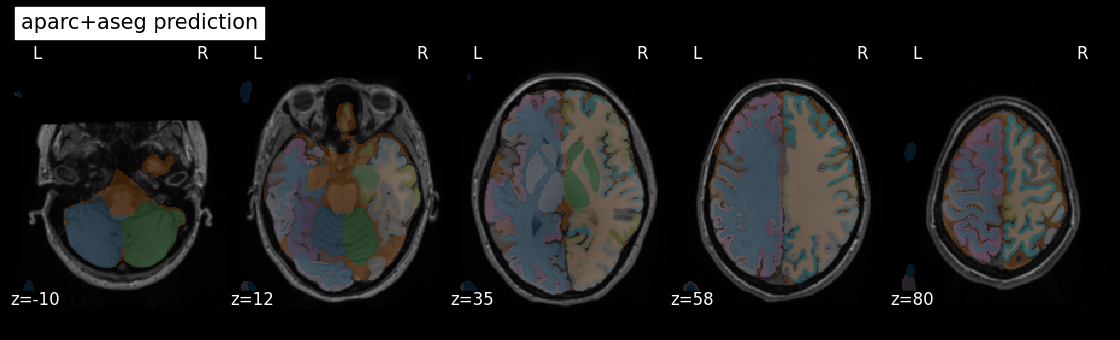

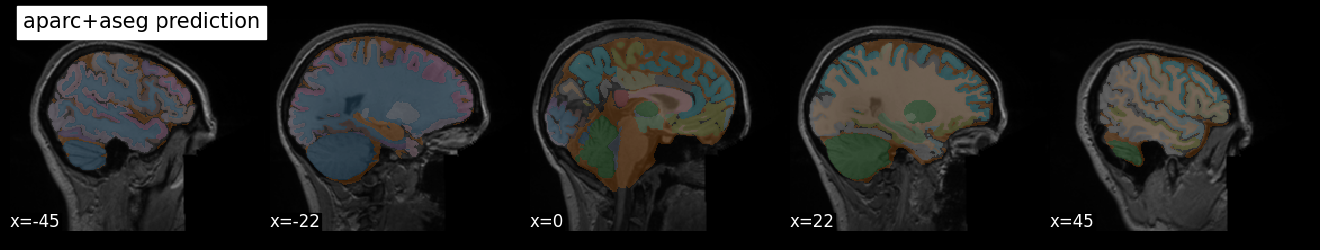

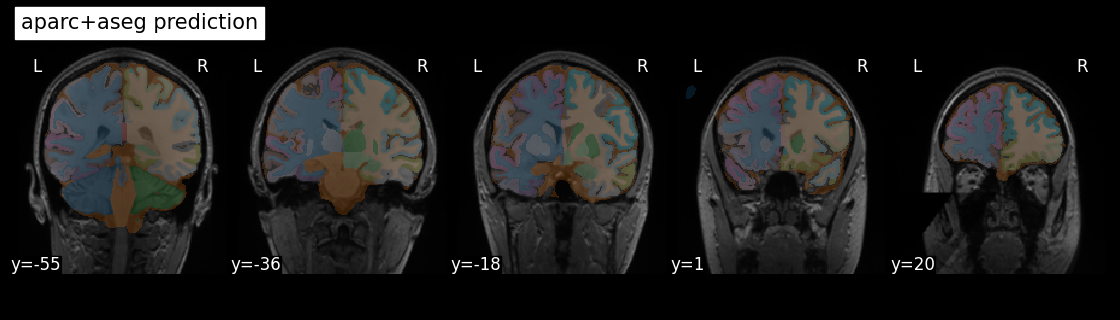

In [24]:
import torch
from nilearn import plotting
import nibabel as nib
from pathlib import Path
from scalesurfer.convert import MNI_AFFINE
import numpy as np

base = Path("/home/rph/scalesurfer/data/subjects_dir/ds002168/mri")

anat = nib.Nifti1Image(torch.load(base / "rawavg.pt").cpu().numpy(), MNI_AFFINE)
aparc = nib.Nifti1Image(torch.load(base / "aparc+aseg.pt").cpu().float().numpy(), MNI_AFFINE)

plotting.plot_roi(
    aparc,
    bg_img=anat,
    title="aparc+aseg prediction",
    cmap="tab20",
    colorbar=False,
    draw_cross=False,
    alpha=0.2,
    # cut_coords=(5, -10, 20),
    display_mode="z",
    cut_coords=np.linspace(-10, 80, 5).round(),
)
plotting.show()

plotting.plot_roi(
    aparc,
    bg_img=anat,
    title="aparc+aseg prediction",
    cmap="tab20",
    colorbar=False,
    draw_cross=False,
    alpha=0.2,
    # cut_coords=(5, -10, 20),
    display_mode="x",
    cut_coords=np.linspace(-45, 45, 5).round(),
)
plotting.show()

plotting.plot_roi(
    aparc,
    bg_img=anat,
    title="aparc+aseg prediction",
    cmap="tab20",
    colorbar=False,
    draw_cross=False,
    alpha=0.2,
    # cut_coords=(5, -10, 20),
    display_mode="y",
    cut_coords=np.linspace(-55, 20, 5).round(),
)
plotting.show()

In [28]:
img = nib.Nifti1Image(
    torch.load("/home/rph/scalesurfer/data/subjects_dir/ds003720/mri/rawavg.pt").cpu().numpy(), MNI_AFFINE
)
nib.save(img, "rawavg.mgz")

In [29]:
img = nib.Nifti1Image(
    torch.load("/home/rph/scalesurfer/data/subjects_dir/ds003720/mri/aparc+aseg.pt").cpu().numpy().astype(np.float32), MNI_AFFINE
)
nib.save(img, "aparc+aseg.mgz")

In [31]:
!freeview \
    -v rawavg.mgz aparc+aseg.mgz \
    -f /home/rph/scalesurfer/data/subjects_dir/ds003720/surf/lh.white \
        /home/rph/scalesurfer/data/subjects_dir/ds003720/surf/lh.pial \
        /home/rph/scalesurfer/data/subjects_dir/ds003720/surf/rh.white \
        /home/rph/scalesurfer/data/subjects_dir/ds003720/surf/rh.pial

Did not find any volume info
Did not find any volume info
Did not find any volume info
Did not find any volume info
